# Лекція 6 — Навчання представлень


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 11  
**Тема лекції:** Навчання представлень та автоенкодери

## Цілі лекції

1. [Що таке представлення?](#representation) — формальне означення, приклади, властивості
2. [Лінійні представлення](#linear) — PCA як лінійне стиснення, обмеження
3. [Нелінійні представлення](#nonlinear) — навчені перетворення, бутилкове горло
4. [Автоенкодери](#ae) — архітектура, функція втрат, зв'язок з PCA
5. [Демонстрація: автоенкодер на цифрах](#demo) — навчання, реконструкція, латентний простір
6. [Денойзинговий автоенкодер](#dae) — навчання стійких представлень
7. [Оцінка якості представлень](#eval) — лінійний зонд, реконструкція, downstream-задача
8. [Порівняння підходів](#comparison) — зведена таблиця


## Налаштування середовища

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Color palette used throughout this lecture
COLORS = ["#2C7BB6", "#D7191C", "#1A9641", "#FDAE61", "#762A83",
          "#4DAC26", "#D01C8B", "#F1B6DA", "#B8E186", "#80CDC1"]


---
<a id='representation'></a>
## 1. Що таке представлення?

### 1.1 Формальне означення

**Представлення** (representation) вхідного об'єкта $x \in \mathcal{X}$ — це вектор $z \in \mathbb{R}^d$,
отриманий за допомогою деякої функції-кодувальника $f : \mathcal{X} \to \mathbb{R}^d$:

$$z = f(x)$$

де $d$ — розмірність латентного простору (latent space).

У різних контекстах $z$ називають по-різному:

| Синонім | Типовий контекст |
|---|---|
| ознаки (features) | класичне ML |
| активації / приховані стани | нейронні мережі |
| ембединги (embeddings) | NLP, рекомендаційні системи |
| код (code) | автоенкодери |
| латентний вектор | генеративні моделі |

Усе це — одна ідея: компактний числовий опис об'єкта, придатний для подальших обчислень.

### 1.2 Що робить представлення хорошим?

Хороше представлення повинно бути:

* **Інформативним**: зберігати ту інформацію, що важлива для цільової задачі.
* **Компактним**: $d \ll \text{dim}(\mathcal{X})$, тобто суттєво менших розмірів, ніж вхід.
* **Узагальненим**: добре переноситись на нові дані, які модель ще не бачила.
* **Перенесеним**: бути корисним не тільки для однієї, але й для суміжних задач.
* **Розплутаним** (disentangled): окремі виміри $z_i$ відповідають різним факторам варіації у даних.

### 1.3 Де ми вже зустрічали представлення?

На попередніх заняттях ми вже будували представлення, не завжди називаючи їх так:

| Тиждень | Метод | Що навчаємо |
|---|---|---|
| 6 | `RepresentationNet` з пляшковим горличком (bottleneck) | 2-D нелінійне представлення (навчена функція $f$) |
| 7–8 | PCA / SVD | Лінійне проектування на головні компоненти |
| 8 | t-SNE / UMAP | Нелінійне вкладення, збереження сусідства |
| 9–10 | GMM: $\mu_k, \Sigma_k$ | Параметричний опис розподілу |

Цього тижня ми формалізуємо ці ідеї і введемо автоенкодер — модель, яка
**спеціально навчена** будувати корисні представлення.

---
<a id='linear'></a>
## 2. Лінійні представлення

### 2.1 Лінійний кодувальник

Найпростіший кодувальник — лінійний:

$$z = Wx, \quad W \in \mathbb{R}^{d \times D}$$

де $D$ — вхідна розмірність, $d$ — бажана розмірність представлення ($d < D$).
Вся виразна сила такого підходу обмежена лінійними підпросторами.

### 2.2 PCA як оптимальне лінійне стиснення

**Метод головних компонент** (PCA), який ми розглядали на тижні 7, є саме таким лінійним кодувальником:

$$z = W_{\text{PCA}}^\top (x - \mu), \quad W_{\text{PCA}} = [v_1 \mid v_2 \mid \ldots \mid v_d]$$

де $v_i$ — власні вектори матриці коваріацій, відсортовані за спаданням власних значень.

**PCA є оптимальним** серед усіх лінійних кодувальників у сенсі мінімізації помилки реконструкції:

$$W_{\text{PCA}} = \arg\min_{W : W^\top W = I} \mathbb{E}\left[\|x - W W^\top (x - \mu) - \mu\|^2\right]$$

Але ключова вимога — **лінійність** матриці $W$. Якщо структура даних нелінійна, PCA не може
побудувати ефективне представлення незалежно від кількості компонент.

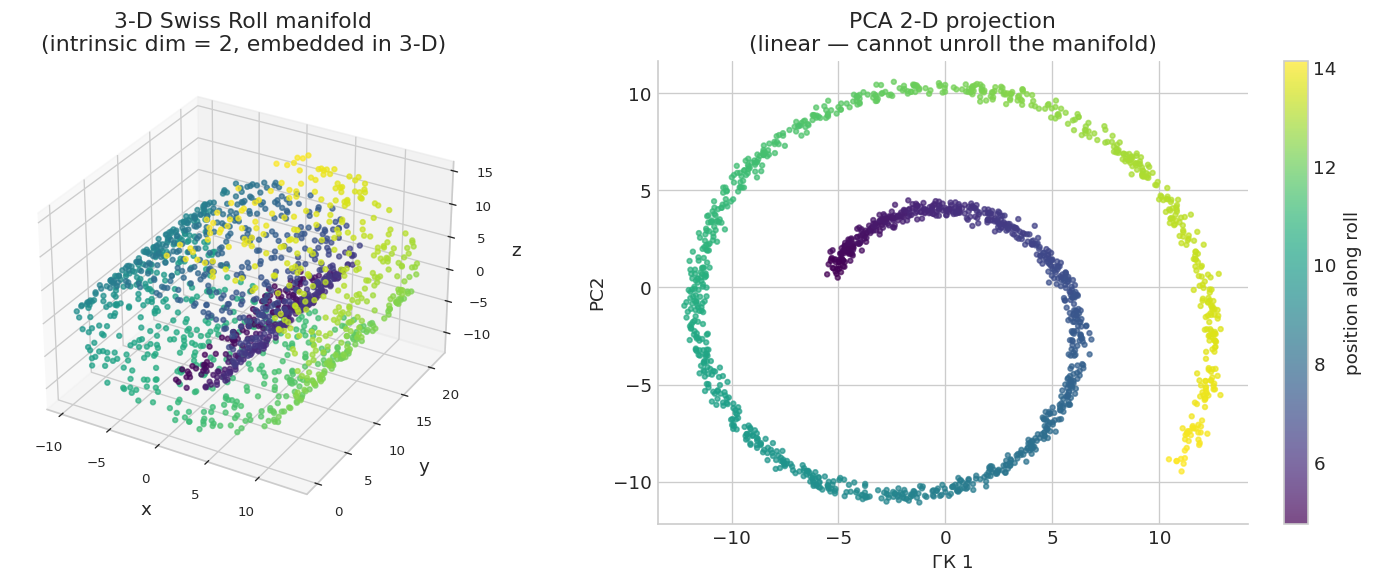

Variance captured by 2 PCs: 71.3%
PCA preserves variance but cannot unfold the non-linear structure.


In [2]:
# Illustrate the limitation of linear representation on the "swiss roll" manifold
from sklearn.datasets import make_swiss_roll

X_roll, color_roll = make_swiss_roll(n_samples=1500, noise=0.2, random_state=RANDOM_STATE)

# PCA to 2-D (linear)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_roll_pca = pca2.fit_transform(X_roll)

fig = plt.figure(figsize=(13, 5))

# 3-D original manifold
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2],
            c=color_roll, cmap="viridis", s=8, alpha=0.7)
ax1.set_title("3-D Swiss Roll manifold\n(intrinsic dim = 2, embedded in 3-D)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax1.tick_params(labelsize=8)

# PCA 2-D projection
ax2 = fig.add_subplot(122)
sc = ax2.scatter(X_roll_pca[:, 0], X_roll_pca[:, 1],
                 c=color_roll, cmap="viridis", s=8, alpha=0.7)
ax2.set_title("PCA 2-D projection\n(linear — cannot unroll the manifold)")
ax2.set_xlabel("ГК 1")
ax2.set_ylabel("PC2")
plt.colorbar(sc, ax=ax2, label="position along roll")
plt.tight_layout()
plt.show()

var2 = pca2.explained_variance_ratio_.sum()
print(f"Variance captured by 2 PCs: {var2 * 100:.1f}%")
print("PCA preserves variance but cannot unfold the non-linear structure.")

#### Що ми бачимо

PCA захоплює ~71% дисперсії у двох компонентах, але «закочена» структура даних
залишається заплутаною — сусіди на рулоні перекриваються у 2-D проекції.
Це класичний приклад, де **лінійного** перетворення недостатньо:
нам потрібна нелінійна функція $f$.

---
<a id='nonlinear'></a>
## 3. Нелінійні представлення

### 3.1 Від лінійних до нелінійних перетворень

Нейронна мережа з кількома шарами реалізує послідовне застосування
нелінійних перетворень:

$$h_0 = x$$
$$h_\ell = \sigma(W_\ell h_{\ell-1} + b_\ell), \quad \ell = 1, \ldots, L$$
$$z = h_L$$

де $\sigma$ — функція активації (ReLU, tanh тощо). Кожен шар може вивертати,
розтягувати і згинати простір даних у будь-який спосіб, який мінімізує задану функцію втрат.

### 3.2 Зв'язок із тижнем 6

На лабораторній роботі 6 ми навчили `RepresentationNet` з 2-D пляшковим горличком:

```
Input (2-D)  →  Linear(2, 32)  →  ReLU  →  Linear(32, 2)  →  ReLU  →  Linear(2, 1)
                                                  ↑
                                          bottleneck (2-D z)
```

Мережа вчилася **класифікувати** (є мітки класів), а представлення виникало як
побічний ефект навчання. Лінійний зонд показав, що після шару act2 (bottleneck)
дані лінійно відокремлювані, а у вхідному просторі — ні.

**Ключове обмеження цього підходу**: нам потрібні **мітки класів** $y$.
Без них ми не можемо сформулювати задачу класифікації і навчити мережу.

### 3.3 А якщо міток немає?

Більшість реальних даних не має міток. Розмічення коштує дорого (час експертів,
гроші). Виникає природне питання: чи можна навчити корисне представлення
**без будь-яких міток**?

Відповідь — **так**. Для цього нам потрібна інша ціль навчання.
Один із найелегантніших підходів — **автоенкодер**.

---
<a id='ae'></a>
## 4. Автоенкодери

### 4.1 Ідея

**Автоенкодер** (autoencoder, AE) — нейронна мережа, яка навчається
стискати дані у компактний код, а потім відновлювати їх з цього коду.

Ціль навчання — мінімізувати **помилку реконструкції**: мережа отримує
вхід $x$, стискає його у вектор $z$, а потім намагається відновити $\hat{x}$ якомога ближчим до $x$.

Ніяких міток не потрібно — **сам вхід служить ціллю**.

### 4.2 Архітектура

Автоенкодер складається з двох частин:

$$\underbrace{f_\theta}_{\text{Encoder}} : x \mapsto z = f_\theta(x)$$
$$\underbrace{g_\phi}_{\text{Decoder}} : z \mapsto \hat{x} = g_\phi(z)$$

```
  Input x          Latent code z         Reconstruction x̂
  (D dims)  →  Encoder  →  (d dims)  →  Decoder  →  (D dims)
               f_θ                          g_φ
```

Кількість нейронів зазвичай симетрично зменшується в енкодері та
зростає в декодері:

```
D → h₁ → h₂ → d → h₂ → h₁ → D
```

### 4.3 Функція втрат

Для неперервних даних використовується **середньоквадратична помилка** (MSE):

$$\mathcal{L}(\theta, \phi) = \frac{1}{n} \sum_{i=1}^{n} \|x_i - g_\phi(f_\theta(x_i))\|^2$$

Для бінарних даних (наприклад, пікселів у діапазоні $[0, 1]$) — **бінарна крос-ентропія**:

$$\mathcal{L}(\theta, \phi) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{D}
  \left[ x_{ij} \log \hat{x}_{ij} + (1 - x_{ij}) \log (1 - \hat{x}_{ij}) \right]$$

Обидві функції диференційовані та оптимізуються через зворотне поширення помилки
і Adam (або SGD) — стандартний конвеєр, який ми вже знаємо.

### 4.4 Чому мережа змушена вчитися корисному представленню?

Якби $d = D$, мережа могла б вирішити задачу тривіально: просто скопіювати вхід
($z = x$, $\hat{x} = z$) і отримати нульову похибку, не вивчивши нічого корисного.

Ключовим є обмеження $d \ll D$. Якщо код коротший за вхід, скопіювати його
неможливо — мережа змушена **стиснути** дані. Щоб реконструкція при цьому
залишалась якісною, код $z$ мусить зберігати саме ту інформацію, яка найбільш
характерна для даних: форму контурів цифри, орієнтацію, наявність петель тощо.
Деталі, які не вміщуються в $d$ вимірів, будуть втрачені.

Таким чином, мінімізація помилки реконструкції за умови вузького коду є
непрямим способом змусити мережу **вивчити структуру даних**.
Автоенкодер із $d < D$ називається **неповним** (undercomplete).

### 4.5 Зв'язок з PCA

**Теорема** (Baldi & Hornik, 1989): якщо кодувальник і декодувальник — **лінійні** функції
і функція втрат — MSE, то автоенкодер навчить рівно ті ж напрямки, що і PCA
(тобто головні компоненти матриці коваріацій).

Таким чином, PCA є окремим випадком автоенкодера з лінійними шарами:

$$f_\theta(x) = W^\top (x - \mu), \quad g_\phi(z) = Wz + \mu$$

Нелінійний автоенкодер є **узагальненням PCA** — він може захопити нелінійну структуру.

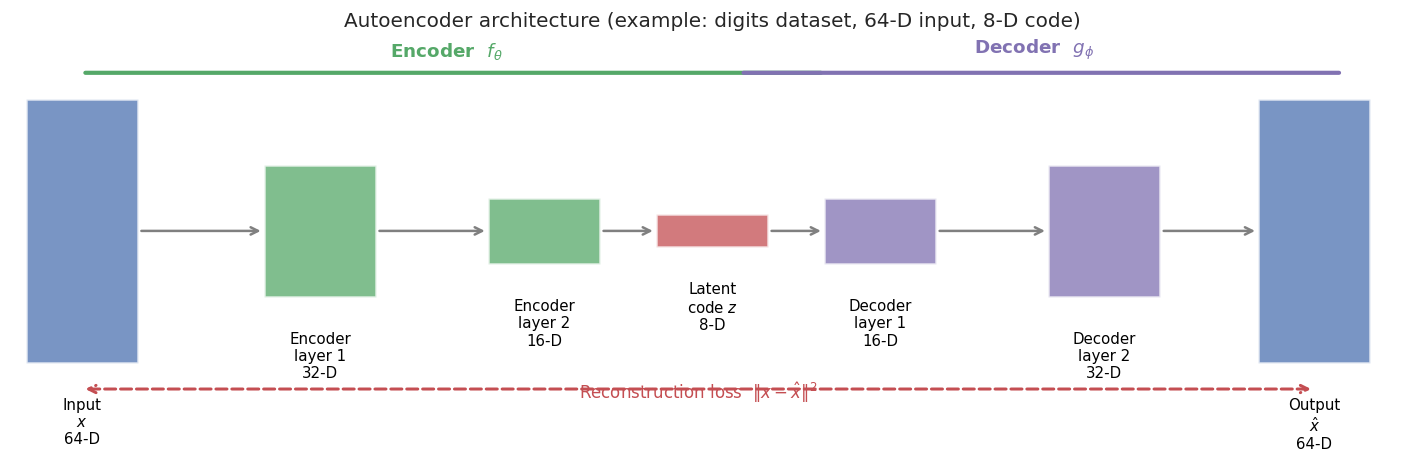

In [3]:
# Visualise the autoencoder architecture as a simple diagram
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Layer positions (x-centre) and sizes
layers = [
    (0.05, 64, "Input\n$x$\n64-D",   "#4C72B0"),
    (0.22, 32, "Encoder\nlayer 1\n32-D",  "#55A868"),
    (0.38, 16, "Encoder\nlayer 2\n16-D",  "#55A868"),
    (0.50,  8, "Latent\ncode $z$\n8-D",   "#C44E52"),
    (0.62, 16, "Decoder\nlayer 1\n16-D",  "#8172B2"),
    (0.78, 32, "Decoder\nlayer 2\n32-D",  "#8172B2"),
    (0.93, 64, "Output\n$\\hat{x}$\n64-D",  "#4C72B0"),
]

max_height = 0.70
for (xc, n, label, color) in layers:
    h = max_height * n / 64
    rect = plt.Rectangle((xc - 0.04, 0.5 - h / 2), 0.08, h,
                          facecolor=color, alpha=0.75, edgecolor="white",
                          linewidth=1.5, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(xc, 0.5 - h / 2 - 0.09, label, ha="center", va="top",
            fontsize=9, transform=ax.transAxes, color="black")

# Arrows between layers
arrow_xs = [(l[0] + 0.04, layers[i+1][0] - 0.04) for i, l in enumerate(layers[:-1])]
for (x1, x2) in arrow_xs:
    ax.annotate("", xy=(x2, 0.5), xytext=(x1, 0.5),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

# Brackets for encoder / decoder
ax.annotate("", xy=(0.58, 0.92), xytext=(0.05, 0.92),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-", color="#55A868", lw=2.5))
ax.text(0.31, 0.95, "Encoder  $f_\\theta$", ha="center", va="bottom",
        fontsize=11, color="#55A868", transform=ax.transAxes, fontweight="bold")

ax.annotate("", xy=(0.95, 0.92), xytext=(0.52, 0.92),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-", color="#8172B2", lw=2.5))
ax.text(0.73, 0.95, "Decoder  $g_\\phi$", ha="center", va="bottom",
        fontsize=11, color="#8172B2", transform=ax.transAxes, fontweight="bold")

# Reconstruction loss annotation
ax.annotate("", xy=(0.93, 0.08), xytext=(0.05, 0.08),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="<->", color="#C44E52", lw=1.8, linestyle="dashed"))
ax.text(0.49, 0.04, r"Reconstruction loss  $\|x - \hat{x}\|^2$",
        ha="center", va="bottom", fontsize=10, color="#C44E52",
        transform=ax.transAxes)

ax.set_title("Autoencoder architecture (example: digits dataset, 64-D input, 8-D code)",
             fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
<a id='demo'></a>
## 5. Демонстрація: автоенкодер на наборі цифр

### 5.1 Дані

Використаємо знайомий `load_digits`: 1 797 зображень цифр 0–9 розміром 8×8 = **64 ознаки**.
Нормалізуємо пікселі у діапазон $[0, 1]$ (ділимо на 16, максимальне значення в цьому наборі).

Ми навчимо автоенкодер **без використання міток** і перевіримо, чи вийшло у нього
знайти корисне представлення за допомогою лінійного зонду.

Train : (1437, 64)   Val : (360, 64)
Pixel range — min: 0.00, max: 1.00


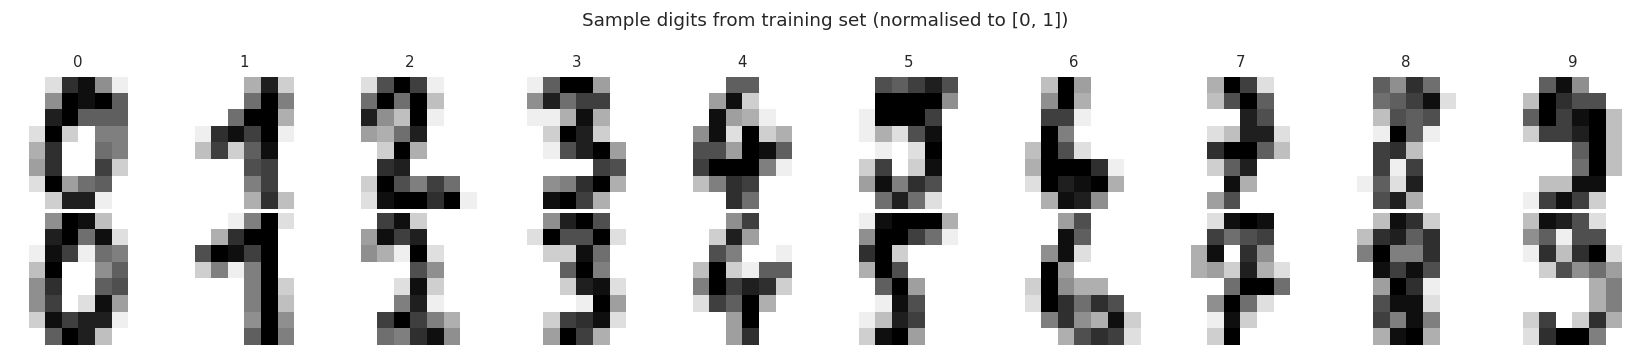

In [4]:
# Load and normalise digits
digits = load_digits()
X_all  = digits.data.astype(np.float32) / 16.0   # scale to [0, 1]
y_all  = digits.target

# Train / validation split (stratified to balance classes)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE
)

print(f"Train : {X_tr.shape}   Val : {X_val.shape}")
print(f"Pixel range — min: {X_all.min():.2f}, max: {X_all.max():.2f}")

# Show a few sample images
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for cls in range(10):
    idx = np.where(y_tr == cls)[0][0]
    axes[0, cls].imshow(X_tr[idx].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
    axes[0, cls].set_title(str(cls), fontsize=9)
    axes[0, cls].axis("off")
    idx2 = np.where(y_tr == cls)[0][1]
    axes[1, cls].imshow(X_tr[idx2].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
    axes[1, cls].axis("off")
plt.suptitle("Sample digits from training set (normalised to [0, 1])", fontsize=11)
plt.tight_layout()
plt.show()

### 5.2 Архітектура автоенкодера

In [5]:
class Autoencoder(nn.Module):
    """Fully-connected symmetric autoencoder for 64-D digit images.

    Architecture:
        Encoder: 64 -> 32 -> latent_dim
        Decoder: latent_dim -> 32 -> 64
    Sigmoid at the output maps values to [0, 1], matching the pixel range.
    """

    def __init__(self, latent_dim: int = 8):
        super().__init__()

        # Encoder: progressively compresses the input
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU(),
        )

        # Decoder: mirrors the encoder, expands back to 64-D
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid(),   # output in [0, 1] to match normalised pixel range
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Return the latent code z for input x."""
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Reconstruct x̂ from latent code z."""
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Full forward pass: x -> z -> x̂."""
        return self.decode(self.encode(x))


# Quick sanity check — shapes
_dummy = torch.zeros(4, 64)
_ae    = Autoencoder(latent_dim=8)
_z     = _ae.encode(_dummy)
_xhat  = _ae(_dummy)
print(f"Input shape      : {_dummy.shape}")
print(f"Latent code shape: {_z.shape}")
print(f"Output shape     : {_xhat.shape}")
print(f"\nTotal parameters : {sum(p.numel() for p in _ae.parameters()):,}")

Input shape      : torch.Size([4, 64])
Latent code shape: torch.Size([4, 8])
Output shape     : torch.Size([4, 64])

Total parameters : 4,744


### 5.3 Навчання

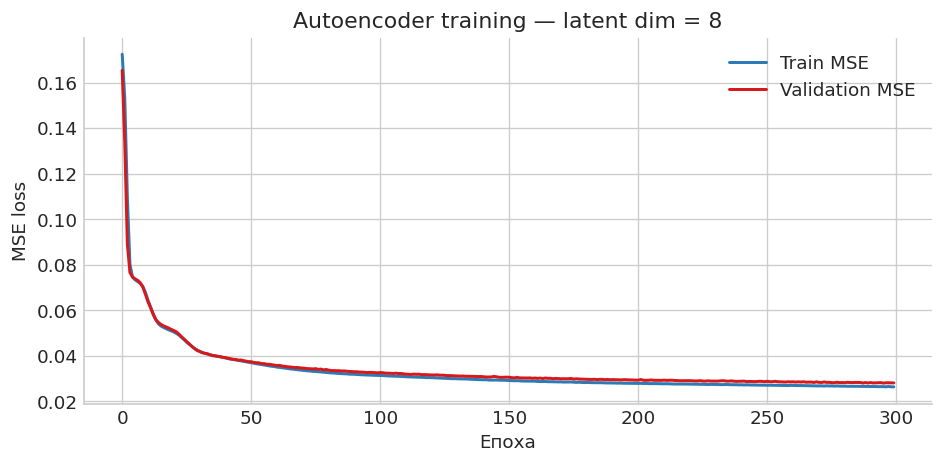

Final train MSE : 0.02632
Final val   MSE : 0.02807


In [6]:
def train_autoencoder(model, X_train, X_val, n_epochs=200, lr=1e-3, batch_size=64):
    """Train the autoencoder and return (train_losses, val_losses).

    Uses MSE loss and Adam optimiser.
    """
    # Convert numpy arrays to PyTorch tensors
    X_tr_t  = torch.tensor(X_train)
    X_val_t = torch.tensor(X_val)

    dataset = TensorDataset(X_tr_t, X_tr_t)   # input == target for AE
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # ---- training ----
        model.train()
        epoch_loss = 0.0
        for x_batch, target_batch in loader:
            optimizer.zero_grad()
            x_hat = model(x_batch)
            loss  = criterion(x_hat, target_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(x_batch)

        train_losses.append(epoch_loss / len(X_train))

        # ---- validation ----
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), X_val_t).item()
        val_losses.append(val_loss)

    return train_losses, val_losses


LATENT_DIM = 8

ae = Autoencoder(latent_dim=LATENT_DIM)
train_losses, val_losses = train_autoencoder(ae, X_tr, X_val,
                                             n_epochs=300, lr=1e-3, batch_size=64)

# Plot learning curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train MSE",      color=COLORS[0], lw=1.8)
ax.plot(val_losses,   label="Validation MSE", color=COLORS[1], lw=1.8)
ax.set_xlabel("Епоха")
ax.set_ylabel("MSE loss")
ax.set_title(f"Autoencoder training — latent dim = {LATENT_DIM}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final train MSE : {train_losses[-1]:.5f}")
print(f"Final val   MSE : {val_losses[-1]:.5f}")

### 5.4 Реконструкція зображень

Порівняємо оригінальні зображення з їхніми реконструкціями.  
Хороша реконструкція свідчить про те, що латентний простір захоплює
головні структурні ознаки цифр.

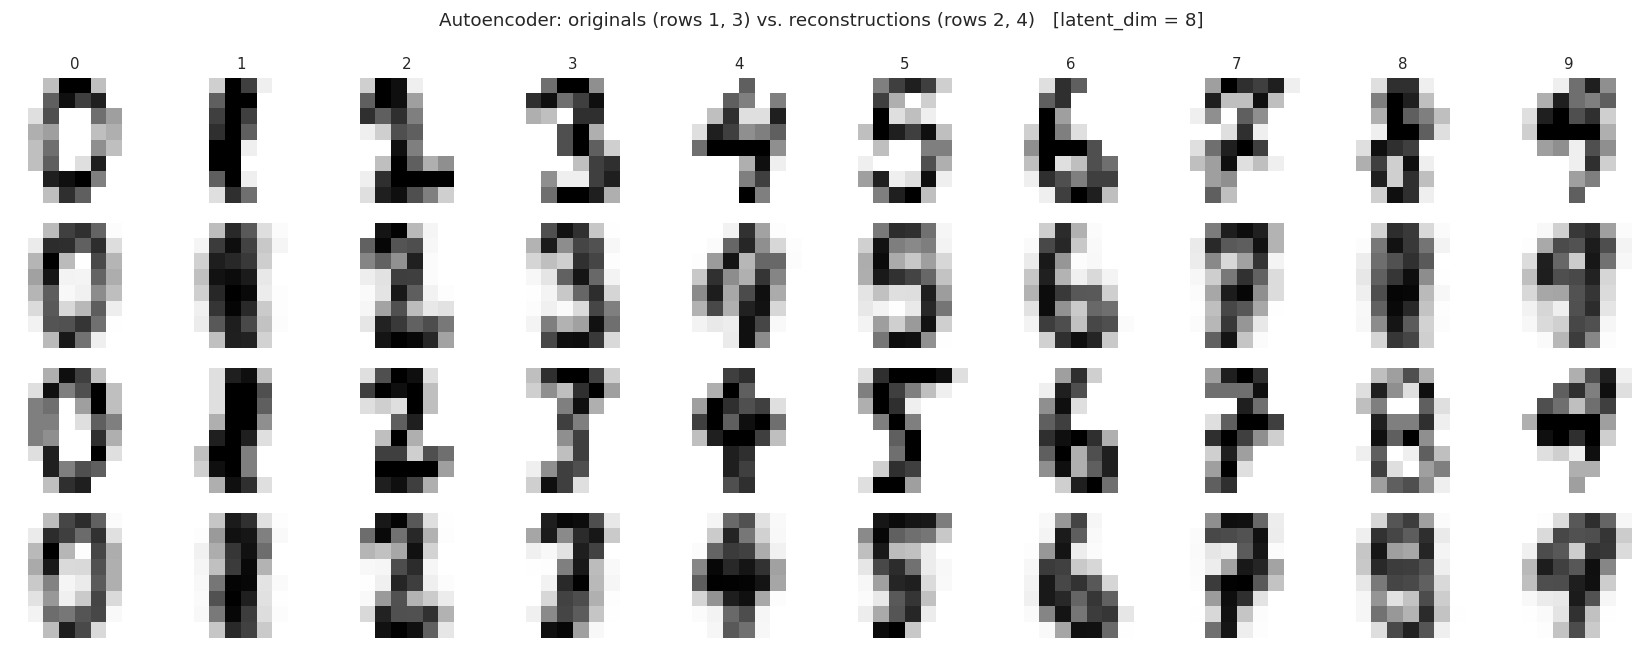

Per-class reconstruction MSE:
  Digit 0: 0.02154  ██████████████████
  Digit 1: 0.02692  ██████████████████████
  Digit 2: 0.02881  ████████████████████████
  Digit 3: 0.02704  ██████████████████████
  Digit 4: 0.02209  ██████████████████
  Digit 5: 0.02936  ████████████████████████
  Digit 6: 0.02314  ███████████████████
  Digit 7: 0.03490  █████████████████████████████
  Digit 8: 0.03588  ██████████████████████████████
  Digit 9: 0.03122  ██████████████████████████


In [7]:
ae.eval()
X_val_t = torch.tensor(X_val)

with torch.no_grad():
    X_val_hat = ae(X_val_t).numpy()   # reconstructions
    Z_val     = ae.encode(X_val_t).numpy()   # latent codes, shape (n_val, 8)

# Show original vs. reconstructed for two samples per digit class
fig, axes = plt.subplots(4, 10, figsize=(14, 5.5))
for cls in range(10):
    idx = np.where(y_val == cls)[0][:2]
    for row_offset, sample_idx in enumerate(idx):
        # Row 0 & 2: originals; Row 1 & 3: reconstructions
        axes[row_offset * 2,     cls].imshow(X_val[sample_idx].reshape(8, 8),
                                              cmap="gray_r", vmin=0, vmax=1)
        axes[row_offset * 2 + 1, cls].imshow(X_val_hat[sample_idx].reshape(8, 8),
                                              cmap="gray_r", vmin=0, vmax=1)
        if row_offset == 0:
            axes[0, cls].set_title(str(cls), fontsize=9)
        for r in range(4):
            axes[r, cls].axis("off")

# Row labels
for row, label in enumerate(["Original", "Reconstructed", "Original", "Reconstructed"]):
    axes[row, 0].set_ylabel(label, fontsize=8, rotation=90, labelpad=2)

plt.suptitle(f"Autoencoder: originals (rows 1, 3) vs. reconstructions (rows 2, 4)   "
             f"[latent_dim = {LATENT_DIM}]", fontsize=11)
plt.tight_layout()
plt.show()

per_class_mse = {}
for cls in range(10):
    mask = y_val == cls
    mse  = np.mean((X_val[mask] - X_val_hat[mask]) ** 2)
    per_class_mse[cls] = mse

print("Per-class reconstruction MSE:")
for cls, mse in per_class_mse.items():
    bar = "█" * int(mse / max(per_class_mse.values()) * 30)
    print(f"  Digit {cls}: {mse:.5f}  {bar}")

### 5.5 Порівняння різних розмірів латентного простору

Чим менший латентний простір, тим сильніше стиснення і тим гіршою може бути реконструкція.  
Знайдемо компроміс між компактністю та якістю.

  latent_dim= 2  val MSE = 0.07412
  latent_dim= 4  val MSE = 0.04268
  latent_dim= 8  val MSE = 0.01759
  latent_dim=16  val MSE = 0.00955
  latent_dim=32  val MSE = 0.00664


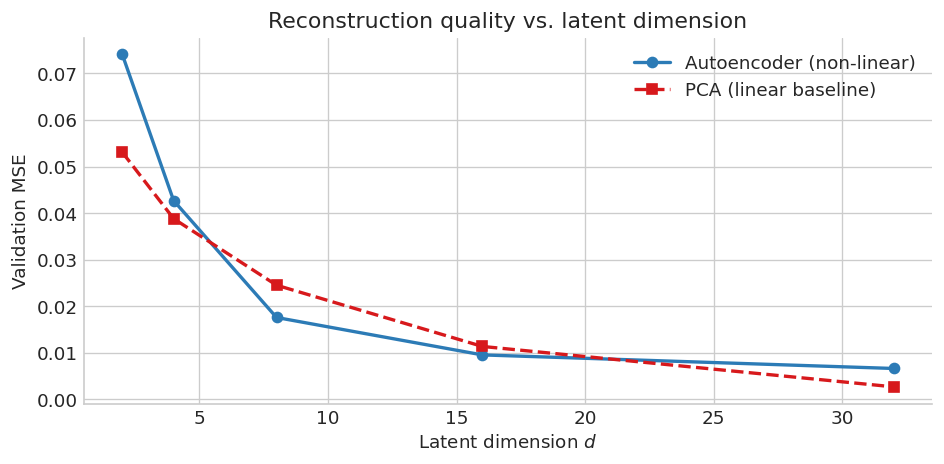

In [8]:
latent_dims  = [2, 4, 8, 16, 32]
mse_results  = {}

for d in latent_dims:
    model_d = Autoencoder(latent_dim=d)
    torch.manual_seed(RANDOM_STATE)
    train_autoencoder(model_d, X_tr, X_val, n_epochs=300, lr=1e-3, batch_size=64)

    model_d.eval()
    with torch.no_grad():
        x_hat_d = model_d(X_val_t).numpy()
    mse_results[d] = np.mean((X_val - x_hat_d) ** 2)
    print(f"  latent_dim={d:2d}  val MSE = {mse_results[d]:.5f}")

# Also record the PCA baseline for each dimensionality
pca_mse = {}
for d in latent_dims:
    pca_d = PCA(n_components=d, random_state=RANDOM_STATE)
    pca_d.fit(X_tr)
    X_pca_recon = pca_d.inverse_transform(pca_d.transform(X_val))
    pca_mse[d] = np.mean((X_val - X_pca_recon) ** 2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(latent_dims, [mse_results[d] for d in latent_dims],
        "o-", color=COLORS[0], lw=2, label="Autoencoder (non-linear)")
ax.plot(latent_dims, [pca_mse[d] for d in latent_dims],
        "s--", color=COLORS[1], lw=2, label="PCA (linear baseline)")
ax.set_xlabel("Latent dimension $d$")
ax.set_ylabel("Validation MSE")
ax.set_title("Reconstruction quality vs. latent dimension")
ax.legend()
plt.tight_layout()
plt.show()

#### Що ми бачимо

* При малих $d$ нелінійний автоенкодер помітно перевершує PCA: нелінійне стиснення
  ефективніше зберігає структуру даних у вузькому коді.
* При великих $d$ різниця зменшується: коли коду достатньо, обидва методи
  відновлюють дані добре.
* Це підтверджує теоретичний зв'язок: лінійний AE = PCA; нелінійний AE є його узагальненням.

### 5.6 Латентний простір і лінійний зонд

Перевіримо, наскільки корисне представлення навчив автоенкодер **без доступу до міток**.
Для цього скористаємося **лінійним зондом** (linear probe), з яким ми вже ознайомились
на лабораторній роботі 6.

Методологія:
1. Кодуємо `X_train` і `X_val` в латентний простір через навчений `ae.encode()`.
2. Навчаємо просту логістичну регресію виключно на латентних кодах.
3. Порівнюємо точність з PCA-представленням такої ж розмірності.

Representation                   Train       Val
--------------------------------------------------
Raw pixels (64-D)               98.7%    95.6%
PCA (8-D)                       90.9%    88.6%
Autoencoder (8-D)               87.5%    85.3%


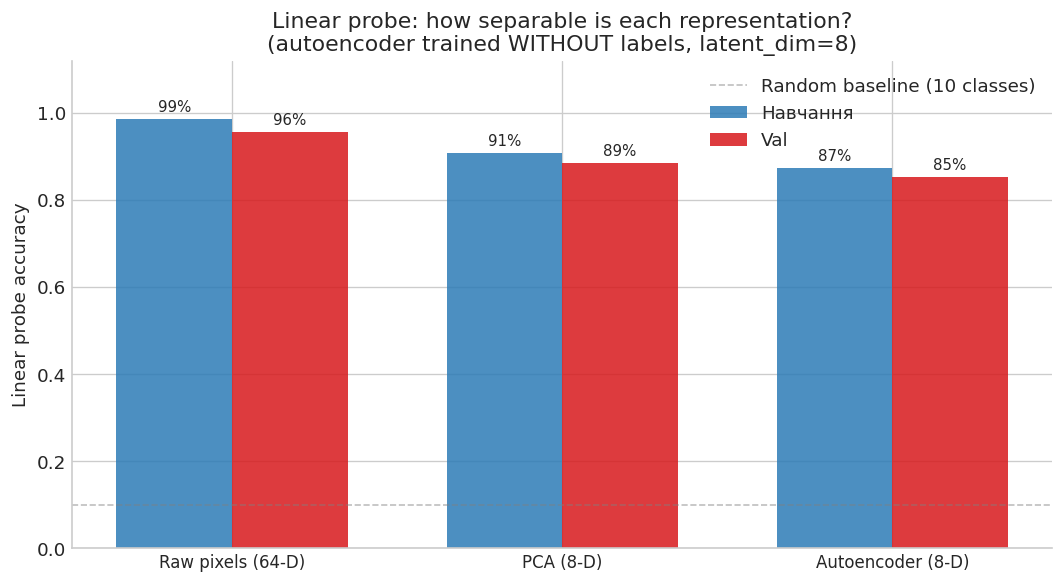

In [9]:
def linear_probe(z_train, y_train, z_val, y_val):
    """Fit a logistic regression on z_train and return (train_acc, val_acc)."""
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(z_train, y_train)
    return clf.score(z_train, y_train), clf.score(z_val, y_val)


# Encode validation and training sets with the 8-D autoencoder
X_tr_t = torch.tensor(X_tr)
ae.eval()
with torch.no_grad():
    Z_tr  = ae.encode(X_tr_t).numpy()
    Z_val = ae.encode(X_val_t).numpy()

# PCA baseline with the same dimensionality
pca8 = PCA(n_components=LATENT_DIM, random_state=RANDOM_STATE)
Z_pca_tr  = pca8.fit_transform(X_tr)
Z_pca_val = pca8.transform(X_val)

# Raw pixels as the simplest baseline
tr_raw,  vl_raw  = linear_probe(X_tr,      y_tr, X_val,      y_val)
tr_ae,   vl_ae   = linear_probe(Z_tr,       y_tr, Z_val,       y_val)
tr_pca,  vl_pca  = linear_probe(Z_pca_tr,   y_tr, Z_pca_val,   y_val)

results = {
    f"Raw pixels (64-D)":          (tr_raw,  vl_raw),
    f"PCA ({LATENT_DIM}-D)":       (tr_pca,  vl_pca),
    f"Autoencoder ({LATENT_DIM}-D)":(tr_ae,   vl_ae),
}

print(f"{'Representation':<28}  {'Train':>8}  {'Val':>8}")
print("-" * 50)
for name, (tr, vl) in results.items():
    print(f"{name:<28}  {tr:>7.1%}  {vl:>7.1%}")

# Bar chart
labels     = list(results.keys())
train_accs = [v[0] for v in results.values()]
val_accs   = [v[1] for v in results.values()]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, train_accs, width, label="Навчання", color=COLORS[0], alpha=0.85)
bars2 = ax.bar(x + width / 2, val_accs,   width, label="Val",   color=COLORS[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Linear probe accuracy")
ax.set_title(f"Linear probe: how separable is each representation?\n"
             f"(autoencoder trained WITHOUT labels, latent_dim={LATENT_DIM})")
ax.axhline(0.10, color="gray", lw=1, ls="--", alpha=0.5, label="Random baseline (10 classes)")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

#### Що ми бачимо

На перший погляд результат може здивувати: автоенкодер поступається і сирим пікселям,
і PCA за точністю лінійного зонду. Чому?

Відповідь лежить у **різних цілях навчання**:

- PCA максимізує дисперсію у проекції — це непряма, але ефективна проксі-ціль для
  збереження класової структури у цифрах.
- Автоенкодер мінімізує MSE реконструкції піксель за пікселем. Ця ціль заохочує
  зберігати глобальну яскравість, загальну форму, рівномірний фон — тобто те, що
  легко реконструювати, а не те, що відрізняє одну цифру від іншої.
- Сирі пікселі (64-D) взагалі не стискаються, тому лінійна модель має доступ до
  повної інформації.

> Лінійний зонд вимірює **лінійну відокремлюваність**, а не загальну якість
> представлення. Автоенкодер може будувати компактний і змістовний код, який
> потребує нелінійного класифікатора для повного розкриття.

Цей результат ставить важливе питання: як навчити представлення, яке є одночасно
компактним **і** дискримінативним — без міток? Саме це питання мотивує методи
контрастивного навчання, які ми розглянемо пізніше.

### 5.7 Візуалізація латентного простору

Оскільки $d = 8$, ми не можемо безпосередньо намалювати латентний простір.
Але ми можемо застосувати PCA або t-SNE до латентних кодів і порівняти
отриману картину з аналогічною проекцією сирих пікселів.

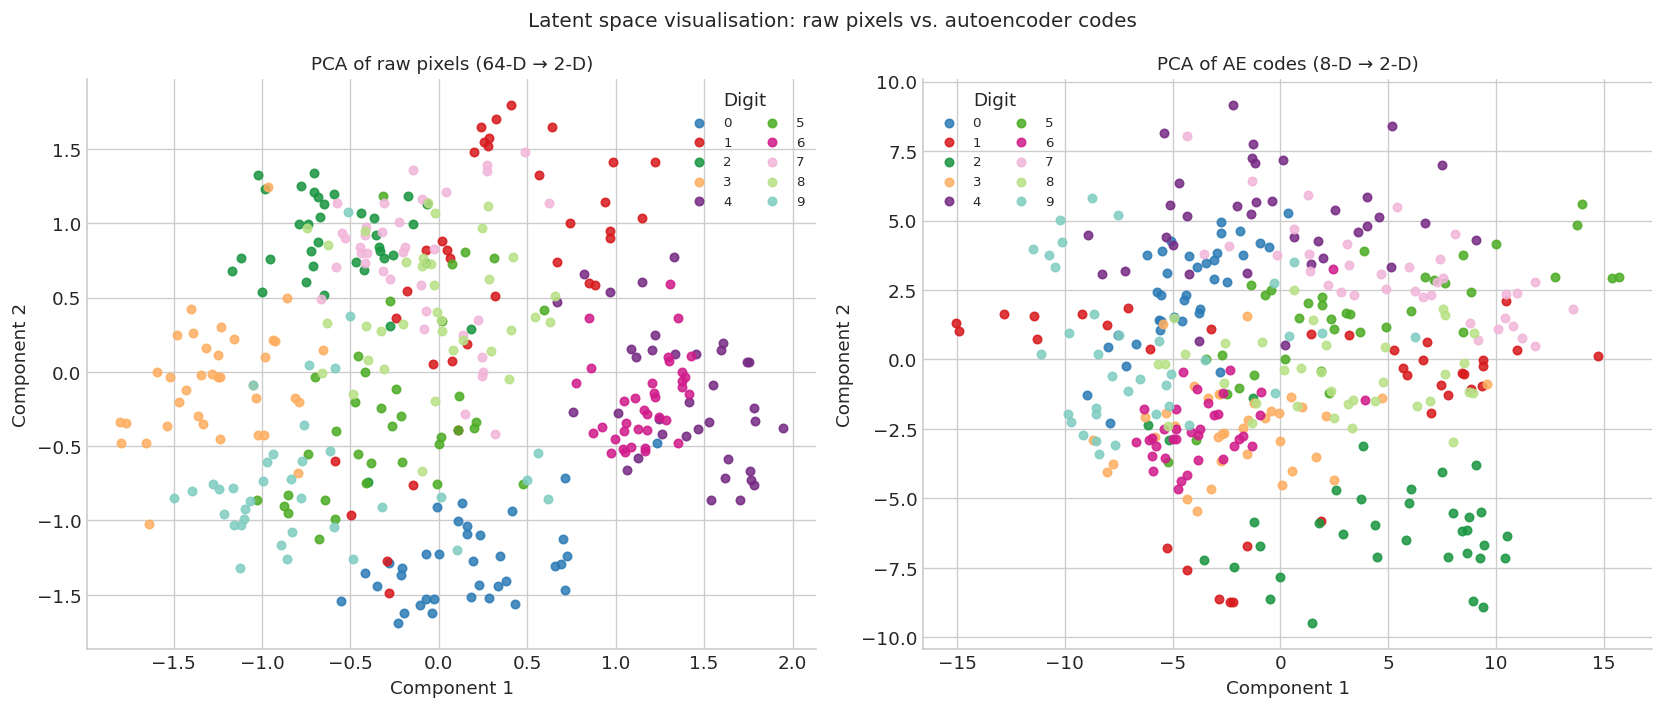

In [10]:
# Project both raw data and latent codes to 2-D using PCA for fair comparison
pca2_raw = PCA(n_components=2, random_state=RANDOM_STATE)
Z2_raw   = pca2_raw.fit_transform(X_val)

pca2_ae  = PCA(n_components=2, random_state=RANDOM_STATE)
Z2_ae    = pca2_ae.fit_transform(Z_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, Z2, title in zip(
    axes,
    [Z2_raw, Z2_ae],
    ["PCA of raw pixels (64-D → 2-D)", f"PCA of AE codes ({LATENT_DIM}-D → 2-D)"]
):
    for cls in range(10):
        mask = y_val == cls
        ax.scatter(Z2[mask, 0], Z2[mask, 1],
                   color=COLORS[cls], label=str(cls), s=25, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(title="Digit", ncol=2, fontsize=8)

plt.suptitle("Latent space visualisation: raw pixels vs. autoencoder codes", fontsize=12)
plt.tight_layout()
plt.show()

#### Що ми бачимо

Обидва графіки виглядають як перемішані хмари точок без чіткого групування за класами.
Це очікувано з тієї ж причини, що й у лінійному зонді: AE не оптимізувався під
відокремленість класів, тому його код не обов'язково організований так, щоб лінійна
проекція розкривала класову структуру.

Крім того, застосування PCA до вже стисненого 8-D коду — це **подвійна** втрата
інформації: спочатку AE стиснув 64-D у 8-D, потім PCA кидає ще 6 із 8 вимірів.

Для коректної візуальної інспекції латентного простору краще підходить **t-SNE**
(тиждень 8), яка зберігає локальну структуру сусідства, а не глобальну дисперсію.
Саме це ви зробите на лабораторній роботі 12: застосуєте t-SNE до латентних кодів
власного автоенкодера та інтерпретуватимете отриману карту.

---
<a id='dae'></a>
## 6. Знешумлюючий автоенкодер

### 6.1 Мотивація

Звичайний автоенкодер стикається з проблемою: при великій ємності декодера
мережа може навчитись **запам'ятовувати** тренувальні приклади замість того,
щоб вивчати загальні закономірності. Це схоже на перенавчання в класифікації.

**Знешумлюючий автоенкодер** (Denoising Autoencoder, DAE; Vincent et al., 2008)
пропонує елегантне регуляризаційне рішення: **навчати відновлювати чистий сигнал
із зашумленого входу**.

### 6.2 Процедура навчання

На кожному кроці:
1. Беремо чисте зображення $x$.
2. Забруднюємо його шумом: $\tilde{x} = x + \varepsilon$, де $\varepsilon \sim \mathcal{N}(0, \sigma^2)$,
   або маскуємо частину пікселів (dropout шуму).
3. Кодуємо зашумлений вхід: $z = f_\theta(\tilde{x})$.
4. Реконструюємо чистий: $\hat{x} = g_\phi(z)$.
5. Мінімізуємо відстань між $\hat{x}$ і **чистим** $x$ (не $\tilde{x}$!):

$$\mathcal{L}_{\text{DAE}} = \mathbb{E}_{x, \varepsilon}\left[\|x - g_\phi(f_\theta(x + \varepsilon))\|^2\right]$$

### 6.3 Чому це регуляризує?

Щоб добре реконструювати чистий $x$ із зашумленого $\tilde{x}$, мережа не може
просто скопіювати вхід. Вона **змушена навчитися статистичній структурі** даних,
щоб "вгадати" відсутню або зашумлену частину.
Представлення, що виходить, є більш стійким та узагальненим.

In [11]:
class DenoisingAutoencoder(nn.Module):
    """Autoencoder trained to reconstruct clean inputs from noisy ones.

    Architecture is identical to Autoencoder; noise is added during forward
    pass only when noise_std > 0.
    """

    def __init__(self, latent_dim: int = 8, noise_std: float = 0.3):
        super().__init__()
        self.noise_std = noise_std

        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add Gaussian noise during training, then encode-decode."""
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            x_noisy = torch.clamp(x + noise, 0.0, 1.0)
        else:
            x_noisy = x
        return self.decoder(self.encoder(x_noisy))


# Train the denoising autoencoder
torch.manual_seed(RANDOM_STATE)
dae = DenoisingAutoencoder(latent_dim=LATENT_DIM, noise_std=0.30)
train_losses_dae, val_losses_dae = train_autoencoder(dae, X_tr, X_val,
                                                      n_epochs=300, lr=1e-3)

# Evaluate: reconstruct from clean inputs (no noise at eval time)
dae.eval()
with torch.no_grad():
    X_dae_hat = dae(X_val_t).numpy()
    Z_dae     = dae.encode(X_val_t).numpy()

dae_mse = np.mean((X_val - X_dae_hat) ** 2)
ae.eval()
with torch.no_grad():
    X_ae_hat = ae(X_val_t).numpy()
ae_mse = np.mean((X_val - X_ae_hat) ** 2)

print(f"Standard AE    val MSE : {ae_mse:.5f}")
print(f"Denoising  AE  val MSE : {dae_mse:.5f}")

# Compare linear probe quality
tr_dae_code = dae.encode(X_tr_t).detach().numpy()
tr_dae, vl_dae = linear_probe(tr_dae_code, y_tr, Z_dae, y_val)
print(f"\nLinear probe — Standard AE : {vl_ae:.1%}")
print(f"Linear probe — Denoising AE: {vl_dae:.1%}")

Standard AE    val MSE : 0.02807
Denoising  AE  val MSE : 0.02266

Linear probe — Standard AE : 85.3%
Linear probe — Denoising AE: 88.3%


### 6.4 Візуальне порівняння: що прибирає знешумлюючий AE?

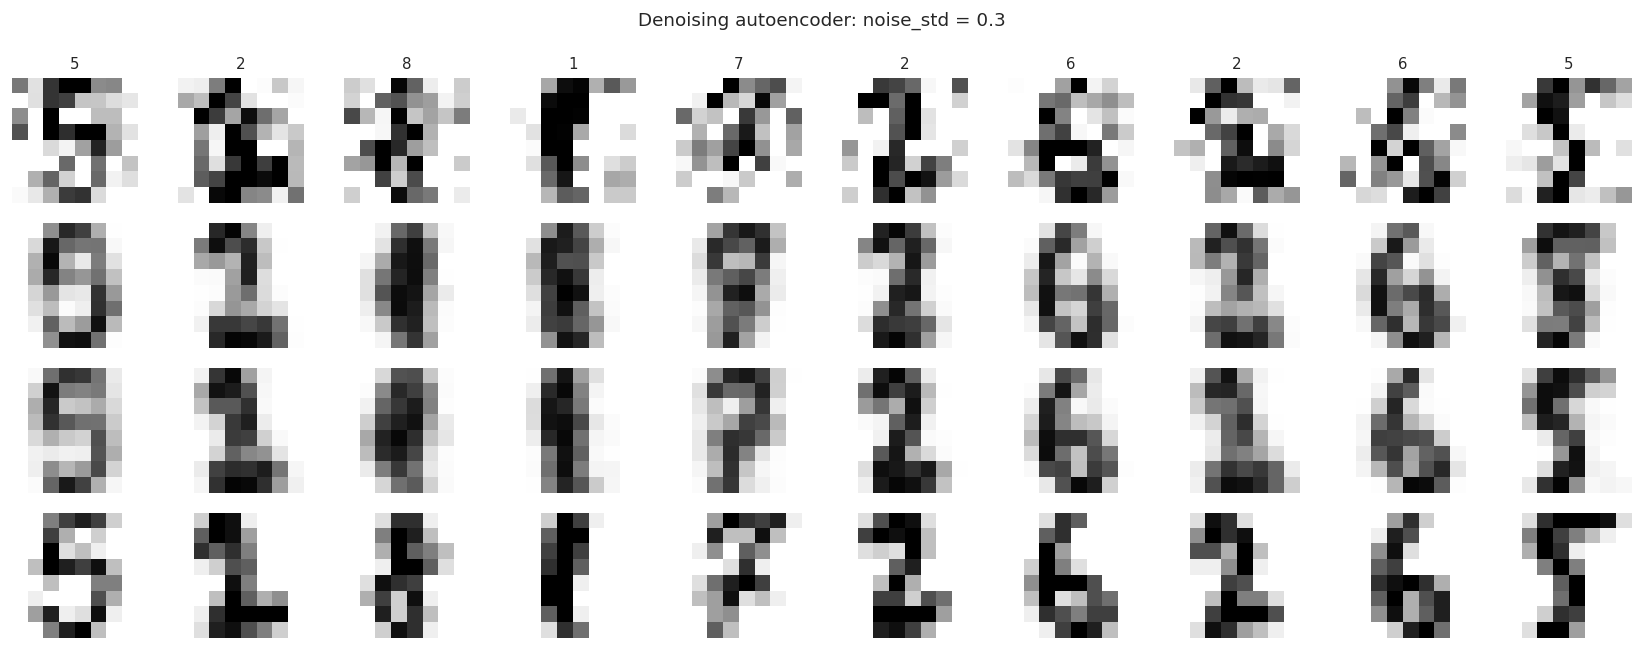

In [12]:
# Show: noisy input | AE reconstruction | DAE reconstruction | original
noise_level = 0.30
np.random.seed(0)

n_show = 10
noisy = np.clip(X_val[:n_show] + np.random.randn(n_show, 64) * noise_level, 0, 1).astype(np.float32)
noisy_t = torch.tensor(noisy)

ae.eval();  dae.eval()
with torch.no_grad():
    ae_recon  = ae(noisy_t).numpy()
    dae_recon = dae(noisy_t).numpy()

fig, axes = plt.subplots(4, n_show, figsize=(14, 5.5))
row_labels = ["Noisy input", "Standard AE", "Denoising AE", "Original"]

for col in range(n_show):
    for row, img in enumerate([noisy[col], ae_recon[col], dae_recon[col], X_val[col]]):
        axes[row, col].imshow(img.reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[0, col].set_title(str(y_val[col]), fontsize=9)

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=3)

plt.suptitle(f"Denoising autoencoder: noise_std = {noise_level}", fontsize=11)
plt.tight_layout()
plt.show()

#### Що ми бачимо

Обидва автоенкодери фактично усувають шум — і стандартний, і знешумлюючий.
Це не дивно: вузький 8-D код фізично не може передати високочастотний шум
з 64 вхідних вимірів, тому обидві моделі «згладжують» вхід незалежно від
того, на яких даних навчались.

Візуальна різниця між рядками 2 і 3 мінімальна. Головна відмінність знешумлюючого
AE проявляється не в якості очищення, а в **стійкості представлення**: його
латентний код менш чутливий до збурень вхідних даних, оскільки під час навчання
модель постійно бачила зашумлені входи і мусила відображати їх у стабільні коди.
Цю властивість ми виміряємо кількісно в наступному розділі через лінійний зонд
і trustworthiness.

---
<a id='eval'></a>
## 7. Оцінка якості представлень

Ключове питання: як кількісно виміряти, наскільки хороше представлення навчила модель?
Існує кілька взаємодоповнюючих підходів.

### 7.1 Помилка реконструкції

Найпростіша метрика — MSE між оригіналом і реконструкцією:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \|x_i - \hat{x}_i\|^2$$

**Переваги:** проста, диференційовна, не потребує міток.

**Недоліки:** низька MSE не гарантує хорошого представлення. Модель може реконструювати
дані, запам'ятавши "середнє" зображення (fuzzy reconstruction), і при цьому
мати поганий латентний простір.

### 7.2 Лінійний зонд (linear probe)

Ми вже використовували цей метод на лабораторній 6. Нагадаємо:

1. Беремо навчену модель і **заморожуємо** її (не оновлюємо ваги).
2. Кодуємо всі дані: $Z = f_\theta(X)$.
3. Навчаємо **лінійний** класифікатор (логістичну регресію) на $(Z, y)$.
4. Оцінюємо точність на валідаційному наборі.

**Що вимірює:** ступінь лінійної відокремлюваності в латентному просторі.
Якщо лінійна модель справляється добре — представлення вже організувало дані
у зручну для використання структуру.

**Чому лінійна модель?** Якщо дозволити нелінійний класифікатор, він може "виправити"
погане представлення власними нелінійностями, і оцінка втратить сенс.

### 7.3 Якість сусідства (Neighborhood quality)

Альтернативний підхід без міток: перевірити, чи зберігається структура сусідства
у латентному просторі.

**Trustworthiness** (Venna & Kaski, 2006): яка частка $k$ найближчих сусідів у $Z$
є також сусідами у вихідному просторі $X$?

$$\text{Trustworthiness}(k) = 1 - \frac{2}{nk(2n-3k-1)} \sum_{i=1}^{n} \sum_{j \in \mathcal{U}_i(k)} \left(r(i,j) - k\right)$$

де $r(i,j)$ — ранг точки $j$ серед сусідів $i$ у вихідному просторі, $\mathcal{U}_i(k)$ — множина
$k$ найближчих сусідів у латентному просторі, яких немає серед $k$ сусідів у вихідному.

### 7.4 Downstream-задача

Найбільш прикладний критерій: наскільки добре представлення допомагає у цільовій задачі
(класифікація, пошук, кластеризація)?

Перевага: безпосередньо вимірює корисність. Недолік: потрібні мітки або інший supervised-сигнал.

In [13]:
# Compute trustworthiness for AE and PCA representations
from sklearn.manifold import trustworthiness

k = 10   # number of neighbours to check

tw_raw = trustworthiness(X_val, X_val,    n_neighbors=k)   # trivial upper bound
tw_pca = trustworthiness(X_val, Z_pca_val, n_neighbors=k)
tw_ae  = trustworthiness(X_val, Z_val,     n_neighbors=k)
tw_dae = trustworthiness(X_val, Z_dae,     n_neighbors=k)

print(f"Trustworthiness (k={k}):")
print(f"  Raw (identity)  : {tw_raw:.4f}  [upper bound = 1.0]")
print(f"  PCA (8-D)       : {tw_pca:.4f}")
print(f"  Autoencoder(8-D): {tw_ae:.4f}")
print(f"  Denoising AE(8-D): {tw_dae:.4f}")

# Summary table — collect all metrics
print("\n" + "=" * 60)
print(f"{'Representation':<25}  {'Linear probe':>12}  {'Trustworthiness':>15}")
print("=" * 60)
for name, vl_probe, tw in [
    (f"PCA ({LATENT_DIM}-D)",          vl_pca, tw_pca),
    (f"AE  ({LATENT_DIM}-D)",          vl_ae,  tw_ae),
    (f"DAE ({LATENT_DIM}-D)",          vl_dae, tw_dae),
]:
    print(f"{name:<25}  {vl_probe:>11.1%}  {tw:>15.4f}")
print("=" * 60)

Trustworthiness (k=10):
  Raw (identity)  : 1.0000  [upper bound = 1.0]
  PCA (8-D)       : 0.9878
  Autoencoder(8-D): 0.9604
  Denoising AE(8-D): 0.9793

Representation             Linear probe  Trustworthiness
PCA (8-D)                        88.6%           0.9878
AE  (8-D)                        85.3%           0.9604
DAE (8-D)                        88.3%           0.9793


#### Що ми бачимо

Обидві метрики узгоджені між собою і підтверджують спостереження попередніх розділів.
PCA лідирує: максимізація дисперсії є непоганою проксі-ціллю для збереження як
класової структури, так і локального сусідства в просторі пікселів.

Найцікавіший результат — DAE: він майже наздоганяє PCA за лінійним зондом (88.3% проти 88.6%)
і помітно перевершує стандартний AE за обома метриками. Причина: знешумлююча цільова функція змушує енкодер відображати зашумлені та чисті версії одного зображення
в одну й ту саму область латентного простору — це неявна регуляризація, яка
водночас підвищує і лінійну відокремлюваність, і якість сусідства.

Стандартний AE займає останнє місце: MSE реконструкції заохочує зберігати
глобальну яскравість і форму, але не дискримінативну структуру.

---
## Підсумок

| Тема | Ключовий висновок |
|---|---|
| **Представлення** | Компактний вектор $z = f(x)$ — основа сучасного ML; якість представлення визначає якість downstream-задач |
| **PCA** | Оптимальне лінійне представлення (мінімум MSE реконструкції); неспроможне захопити нелінійну структуру |
| **Нелінійні представлення** | Нейронні мережі з'являються як природне узагальнення: стек нелінійних перетворень може відобразити будь-яку структуру |
| **Автоенкодер** | Навчається представленню без міток; ціль — реконструкція вхідних даних; лінійний AE з MSE = PCA |
| **Знешумлюючий AE** | Навчання відновлювати з шуму змушує модель вивчати статистику чистих даних; покращує якість і стійкість представлення |
| **Оцінка представлень** | Жодна одна метрика не є вичерпною; комбінація MSE, лінійного зонду та trustworthiness дає повну картину |